In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nibabel.processing import resample_from_to
import json
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
subject_id = "sub-03"

# Portable project/data roots: Linux mounts external drives under /media, macOS under /Volumes.
project_root = Path.cwd()
if not (project_root / "DCM.ipynb").exists():
    project_root = Path("/Volumes/T7 Shield/PycharmProjects/MIPLAB")

candidate_roots = [
    Path("/Volumes/T7 Shield/derivatives_MNIcohort3"),
    Path("/media/lea/T7 Shield/derivatives_MNIcohort3"),
    Path('/Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3')
]
data_root = next((p for p in candidate_roots if p.exists()), candidate_roots[0])

# Expensive cells are opt-in. Set RUN_MATLAB=True only when you really want to launch SPM estimation.
RUN_MATLAB = True
FORCE_RECOMPUTE = False

fmri_dir = data_root / subject_id / "func"
events_dir = data_root / subject_id / "func"
out_dir = events_dir / "dcm_results"
out_dir.mkdir(parents=True, exist_ok=True)

TR = 2.0

tasks = ["MDOD", "MDOG", "MGOD", "MGOG"]

def _extract_run_number(path):
    name = path.name
    marker = "_run-"
    if marker not in name:
        return -1
    start = name.index(marker) + len(marker)
    digits = []
    for ch in name[start:]:
        if ch.isdigit():
            digits.append(ch)
        else:
            break
    return int("".join(digits)) if digits else -1

def resolve_task_bold_file(task):
    # Prefer canonical preproc_bold files, but accept cohort folders where the
    # 4D BOLD file is named *_bold.nii.gz. Exclude boldref images because they
    # are single-volume references, not time series.
    preferred_pattern = f"{subject_id}_task-{task}*_desc-preproc_bold.nii.gz"
    candidates = sorted(fmri_dir.glob(preferred_pattern))

    if not candidates:
        fallback_pattern = f"{subject_id}_task-{task}*_bold.nii.gz"
        candidates = sorted(
            p for p in fmri_dir.glob(fallback_pattern)
            if "boldref" not in p.name
        )

    if not candidates:
        raise FileNotFoundError(
            f"No 4D BOLD file found for task {task} in {fmri_dir} "
            f"(tried: {preferred_pattern} and *_bold.nii.gz excluding boldref)"
        )

    # If multiple runs exist, keep the latest run number (e.g., run-2).
    return sorted(candidates, key=lambda p: (_extract_run_number(p), p.name))[-1]

fmri_files = {}
events_files = {}
available_tasks = []

for t in tasks:
    try:
        # On essaie de trouver le fichier BOLD pour la tâche
        bold_file = resolve_task_bold_file(t)
        csv_file = events_dir / f"{subject_id}_task_{t}.csv"

        # On vérifie que le fichier d'événements CSV existe aussi
        if csv_file.exists():
            fmri_files[t] = bold_file
            events_files[t] = csv_file
            available_tasks.append(t)
        else:
            print(f"  [Avertissement] Fichier CSV manquant pour la tâche {t}, tâche ignorée.")
    except FileNotFoundError:
        print(f"  [Avertissement] Données fMRI manquantes pour la tâche {t}, tâche ignorée.")

# On remplace la liste globale par les tâches réellement trouvées pour ce sujet
tasks = available_tasks

events_files = {
    t: events_dir / f"{subject_id}_task_{t}.csv"
    for t in tasks
}

glm_dir = data_root / "mask"
roi_masks = {
    "M1_L": glm_dir / "M1_L_sphere.nii.gz",
    "M1_R": glm_dir / "M1_R_sphere.nii.gz",
    "A1_L": glm_dir / "A1_L_sphere.nii.gz",
    "A1_R": glm_dir / "A1_R_sphere.nii.gz",
    "V1_L": glm_dir / "V1_L_sphere.nii.gz",
    "V1_R": glm_dir / "V1_R_sphere.nii.gz",
}

region_names = ["M1_L","M1_R","A1_L","A1_R","V1_L","V1_R"]
input_names = [
    "visual_L_uncrossed", "visual_R_uncrossed",
    "auditory_L_uncrossed", "auditory_R_uncrossed",
    "visual_L_crossed", "visual_R_crossed",
    "auditory_L_crossed", "auditory_R_crossed",
]

print(f"Data root: {data_root}")
print(f"Output directory: {out_dir}")
print("Resolved BOLD files:")
for t, p in fmri_files.items():
    print(f"  {t}: {p.name}")


  [Avertissement] Données fMRI manquantes pour la tâche MGOD, tâche ignorée.
Data root: /Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3
Output directory: /Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results
Resolved BOLD files:
  MDOD: sub-03_task-MDOD_space-MNIPediatricAsym_cohort-3_res-1_desc-preproc_bold.nii.gz
  MDOG: sub-03_task-MDOG_run-2_space-MNIPediatricAsym_cohort-3_res-1_desc-preproc_bold.nii.gz
  MGOG: sub-03_task-MGOG_space-MNIPediatricAsym_cohort-3_res-1_desc-preproc_bold.nii.gz


In [3]:
# Preflight check for selected subject (run after changing subject_id).

missing = []

if not fmri_dir.exists():
    missing.append(f"Missing fMRI directory: {fmri_dir}")
if not events_dir.exists():
    missing.append(f"Missing events directory: {events_dir}")
if not glm_dir.exists():
    missing.append(f"Missing ROI mask directory: {glm_dir}")

# 1. Vérification des fichiers BOLD (Uniquement pour les tâches disponibles trouvées à l'étape précédente)
for task, fpath in fmri_files.items():
    if not fpath.exists():
        missing.append(f"Missing BOLD file for {task}: {fpath}")

# 2. Vérification des fichiers d'événements (Uniquement pour les tâches disponibles)
for task, epath in events_files.items():
    if not epath.exists():
        missing.append(f"Missing events CSV for {task}: {epath}")

# 3. Vérification des masques (Dans le dossier centralisé)
for roi_name, mpath in roi_masks.items():
    if not mpath.exists():
        missing.append(f"Missing ROI mask {roi_name}: {mpath}")

# Sécurité : On s'assure qu'il reste au moins une tâche à analyser pour ce sujet
if not fmri_files:
    missing.append("Aucune tâche fMRI valide et complète (BOLD + CSV) n'a été trouvée pour ce sujet.")

if missing:
    print("\nPreflight FAILED for subject", subject_id)
    print("Found", len(missing), "issue(s):")
    for msg in missing:
        print(" -", msg)
    raise FileNotFoundError("Preflight failed. Fix missing inputs before running downstream DCM cells.")
else:
    print("\nPreflight OK for subject", subject_id)
    print("All required inputs found:")
    print(" -", len(fmri_files), f"BOLD files (Tâches gérées : {list(fmri_files.keys())})")
    print(" -", len(events_files), "events CSV files")
    print(" -", len(roi_masks), "ROI masks")
    print("Output directory:", out_dir)


Preflight OK for subject sub-03
All required inputs found:
 - 3 BOLD files (Tâches gérées : ['MDOD', 'MDOG', 'MGOG'])
 - 3 events CSV files
 - 6 ROI masks
Output directory: /Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results


In [4]:
CODE_TO_LABEL = {
    1:  "left_sight_alone",
    2:  "right_sight_alone",
    10: "left_ear_alone",
    20: "right_ear_alone",
    11: "left_audio_visual",
    22: "right_audio_visual",
}

# mapping vers côtés
TRIGGER_TO_SIDES = {
    1:  {"visual": "L"},
    2:  {"visual": "R"},
    10: {"auditory": "L"},
    20: {"auditory": "R"},
    11: {"visual": "L", "auditory": "L"},
    22: {"visual": "R", "auditory": "R"},
}

# main depuis nom de tâche
TASK_TO_MOTOR = {
    "MDOD": "R",
    "MDOG": "R",
    "MGOD": "L",
    "MGOG": "L",
}

In [5]:
def build_roi_indices(reference_fmri_file, roi_masks):
    """Pré-calcule les indices voxels ROI dans l'espace aplati du volume 3D."""
    ref_img = nib.load(str(reference_fmri_file))
    spatial_shape = ref_img.shape[:3]
    ref_affine = ref_img.affine

    roi_indices = {}
    for name, mask_path in roi_masks.items():
        mask_img = nib.load(str(mask_path))

        # Si la grille diffère (shape/affine), on réaligne le masque sur le fMRI.
        if mask_img.shape != spatial_shape or not np.allclose(mask_img.affine, ref_affine):
            mask_img = resample_from_to(mask_img, ref_img.slicer[:, :, :, 0], order=0)

        mask = np.asarray(mask_img.dataobj) > 0
        flat_idx = np.flatnonzero(mask.ravel())

        if flat_idx.size == 0:
            raise ValueError(f"Mask {name} is empty after resampling to fMRI grid")

        roi_indices[name] = flat_idx

    return roi_indices


def extract_roi_timeseries(fmri_file, roi_indices):
    img = nib.load(str(fmri_file))
    data = np.asarray(img.dataobj, dtype=np.float32)
    n_scans = data.shape[-1]
    data_2d = data.reshape(-1, n_scans)

    ts_dict = {}

    for name, flat_idx in roi_indices.items():
        ts = data_2d[flat_idx, :].mean(axis=0)

        # z-score robuste pour éviter les divisions par 0
        std = ts.std()
        ts = (ts - ts.mean()) / std if std > 0 else np.zeros_like(ts)
        ts_dict[name] = ts

    return pd.DataFrame(ts_dict)

In [6]:
def read_events_file(events_file):
    """
    Lit un fichier events avec préambule avant la vraie table.
    Cherche la ligne d'en-tête (onset/duration/trigger).
    """
    import pandas as pd
    from io import StringIO

    with open(events_file, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    header_idx = None
    sep = ","

    for i, line in enumerate(lines):
        cleaned = line.replace("\ufeff", "").strip().lower()
        if not cleaned:
            continue

        if "onset" in cleaned and "duration" in cleaned and "trigger" in cleaned:
            header_idx = i
            if ";" in cleaned:
                sep = ";"
            elif "\t" in cleaned:
                sep = "\t"
            else:
                sep = ","
            break

    if header_idx is None:
        raise ValueError(f"Impossible de trouver la ligne d'en-tête dans {events_file}")

    header_line = lines[header_idx].replace("\ufeff", "").strip()
    columns = [c.strip().lower() for c in header_line.split(sep)]
    body = "".join(lines[header_idx + 1:])

    df = pd.read_csv(StringIO(body), sep=sep, names=columns, header=None)
    df.columns = [str(c).replace("\ufeff", "").strip().lower() for c in df.columns]
    df = df.dropna(how="all").reset_index(drop=True)

    required = {"onset", "duration", "trigger"}
    if not required.issubset(df.columns):
        raise ValueError(
            f"Colonnes manquantes dans {events_file}. Trouvé: {list(df.columns)}; attendu: {sorted(required)}"
        )

    return df


def opposite_side(side):
    return "R" if side == "L" else "L"


def condition_for_stimulus(task_name, stimulus_side):
    motor_side = TASK_TO_MOTOR[task_name]
    return "uncrossed" if stimulus_side == motor_side else "crossed"


def input_name_for(modality, stimulus_side, task_name):
    condition = condition_for_stimulus(task_name, stimulus_side)
    return f"{modality}_{stimulus_side}_{condition}"


def split_input_name(input_name):
    modality, side, condition = input_name.split("_")
    return modality, side, condition


def build_U(events_df, task_name, n_scans):
    """Build condition-gated inputs: modality_side_uncrossed/crossed."""
    U = np.zeros((n_scans, len(input_names)))
    col = {k: i for i, k in enumerate(input_names)}

    for _, row in events_df.iterrows():
        onset = float(row["onset"])
        duration = float(row["duration"])
        trigger = int(row["trigger"])

        start = max(0, int(np.floor(onset / TR)))
        end = min(n_scans, int(np.ceil((onset + duration) / TR)))
        if end <= start:
            end = min(n_scans, start + 1)

        info = TRIGGER_TO_SIDES.get(trigger, {})
        for modality, stimulus_side in info.items():
            name = input_name_for(modality, stimulus_side, task_name)
            if name not in col:
                raise KeyError(f"Input {name} is missing from input_names")
            U[start:end, col[name]] = 1

    return pd.DataFrame(U, columns=input_names)

In [7]:
REGION_INDEX = {"M1_L": 0, "M1_R": 1, "A1_L": 2, "A1_R": 3, "V1_L": 4, "V1_R": 5}


def sensory_region(modality, side):
    prefix = "V1" if modality == "visual" else "A1"
    return f"{prefix}_{side}"


def motor_region(side):
    return f"M1_{side}"


def _add_connection(mat, target, source, value=1.0):
    mat[REGION_INDEX[target], REGION_INDEX[source]] = value


def build_A():
    """Intrinsic baseline matrix: same-hemisphere sensory-to-motor architecture only."""
    A = np.eye(len(region_names))
    for side in ["L", "R"]:
        _add_connection(A, motor_region(side), sensory_region("visual", side))
        _add_connection(A, motor_region(side), sensory_region("auditory", side))
    return A


def build_C():
    """Input matrix: every condition-specific input enters its sensory source ROI."""
    C = np.zeros((len(region_names), len(input_names)))
    for j, name in enumerate(input_names):
        modality, side, _condition = split_input_name(name)
        C[REGION_INDEX[sensory_region(modality, side)], j] = 1.0
    return C


def add_uncrossed_policy_connections(B_mat, modality, stim_side, uncrossed_policy):
    sensory_src = sensory_region(modality, stim_side)
    local_motor = motor_region(stim_side)
    contra_side = opposite_side(stim_side)
    contra_motor = motor_region(contra_side)
    contra_sensory = sensory_region(modality, contra_side)

    _add_connection(B_mat, local_motor, sensory_src)

    if uncrossed_policy == "INTRA_ONLY":
        return
    if uncrossed_policy == "FLEX":
        _add_connection(B_mat, contra_motor, local_motor)
        _add_connection(B_mat, contra_motor, sensory_src)
        _add_connection(B_mat, contra_sensory, sensory_src)
        _add_connection(B_mat, contra_motor, contra_sensory)
        return
    raise ValueError(f"Unknown uncrossed_policy: {uncrossed_policy}")


def add_crossed_pathway_connections(B_mat, modality, stim_side, pathway_type):
    sensory_src = sensory_region(modality, stim_side)
    local_motor = motor_region(stim_side)
    contra_side = opposite_side(stim_side)
    contra_motor = motor_region(contra_side)
    contra_sensory = sensory_region(modality, contra_side)

    if pathway_type == "NULL":
        _add_connection(B_mat, local_motor, sensory_src)
    elif pathway_type == "RELAY":
        _add_connection(B_mat, local_motor, sensory_src)
        _add_connection(B_mat, contra_motor, local_motor)
    elif pathway_type == "DIRECT":
        _add_connection(B_mat, contra_motor, sensory_src)
    elif pathway_type == "SENSORY_RELAY":
        _add_connection(B_mat, contra_sensory, sensory_src)
        _add_connection(B_mat, contra_motor, contra_sensory)
    else:
        raise ValueError(f"Unknown pathway_type: {pathway_type}")


def build_B(task_name=None, pathway_type="NULL", uncrossed_policy="INTRA_ONLY"):
    """
    Condition-gated modulatory matrices.

    The model space tests crossed pathway hypotheses crossed with two uncrossed
    policies: INTRA_ONLY vs FLEX.
    """
    pathway_type = pathway_type.upper()
    uncrossed_policy = uncrossed_policy.upper()
    B = {name: np.zeros((len(region_names), len(region_names))) for name in input_names}

    for name in input_names:
        modality, stim_side, condition = split_input_name(name)
        if condition == "uncrossed":
            add_uncrossed_policy_connections(B[name], modality, stim_side, uncrossed_policy)
        elif condition == "crossed":
            add_crossed_pathway_connections(B[name], modality, stim_side, pathway_type)
        else:
            raise ValueError(f"Unknown condition in input name: {name}")

    return B


def summarize_B_connections(B):
    rows = []
    for input_name, mat in B.items():
        for target_idx, source_idx in np.argwhere(mat != 0):
            rows.append({
                "input": input_name,
                "source": region_names[source_idx],
                "target": region_names[target_idx],
                "value": float(mat[target_idx, source_idx]),
                "same_hemisphere": region_names[source_idx].split("_")[-1] == region_names[target_idx].split("_")[-1],
            })
    return pd.DataFrame(rows)

## Verify uncrossed condition connectivity

This diagnostic checks whether the `UNC_INTRA_ONLY` family really keeps uncrossed condition-specific modulations inside the same hemisphere.

In [8]:
def _roi_hemi(region_name):
    return region_name.split("_")[-1]


def verify_uncrossed_same_hemisphere(A=None, B=None, verbose=True):
    """Check whether uncrossed INTRA_ONLY inputs modulate only same-hemisphere pathways."""
    A = build_A() if A is None else A
    B = build_B(pathway_type="NULL", uncrossed_policy="INTRA_ONLY") if B is None else B

    rows = []
    issues = []

    for task, motor_side in TASK_TO_MOTOR.items():
        for trigger, side_info in TRIGGER_TO_SIDES.items():
            for modality, stim_side in side_info.items():
                if stim_side != motor_side:
                    continue

                input_name = input_name_for(modality, stim_side, task)
                mat = B[input_name]
                nonzero = np.argwhere(mat != 0)

                for target_idx, source_idx in nonzero:
                    source = region_names[source_idx]
                    target = region_names[target_idx]
                    same_hemi = _roi_hemi(source) == _roi_hemi(target) == motor_side
                    row = {
                        "task": task,
                        "trigger": trigger,
                        "motor_side": motor_side,
                        "input": input_name,
                        "source": source,
                        "target": target,
                        "value": float(mat[target_idx, source_idx]),
                        "same_hemisphere": bool(same_hemi),
                    }
                    rows.append(row)
                    if not same_hemi:
                        issues.append(row)

    static_cross_rows = []
    for target_idx, source_idx in np.argwhere(A != 0):
        if target_idx == source_idx:
            continue
        source = region_names[source_idx]
        target = region_names[target_idx]
        if _roi_hemi(source) != _roi_hemi(target):
            static_cross_rows.append({"source": source, "target": target, "value": float(A[target_idx, source_idx])})

    uncrossed_df = pd.DataFrame(rows)
    static_cross_df = pd.DataFrame(static_cross_rows)

    if verbose:
        print("UNCROSSED INTRA_ONLY B-MATRIX CHECK")
        print("Result:", "OK - all uncrossed B modulations are same-hemisphere" if not issues else "FAILED")
        if not uncrossed_df.empty:
            print(uncrossed_df.to_string(index=False))
        print("\nSTATIC A-MATRIX CROSS-HEMISPHERIC CONNECTIONS")
        print("None - crossed hypotheses are gated in B, not always active in A." if static_cross_df.empty else static_cross_df.to_string(index=False))

    return uncrossed_df, static_cross_df, issues


uncrossed_df, static_cross_df, uncrossed_issues = verify_uncrossed_same_hemisphere()

UNCROSSED INTRA_ONLY B-MATRIX CHECK
Result: OK - all uncrossed B modulations are same-hemisphere
task  trigger motor_side                input source target  value  same_hemisphere
MDOD        2          R   visual_R_uncrossed   V1_R   M1_R    1.0             True
MDOD       20          R auditory_R_uncrossed   A1_R   M1_R    1.0             True
MDOD       22          R   visual_R_uncrossed   V1_R   M1_R    1.0             True
MDOD       22          R auditory_R_uncrossed   A1_R   M1_R    1.0             True
MDOG        2          R   visual_R_uncrossed   V1_R   M1_R    1.0             True
MDOG       20          R auditory_R_uncrossed   A1_R   M1_R    1.0             True
MDOG       22          R   visual_R_uncrossed   V1_R   M1_R    1.0             True
MDOG       22          R auditory_R_uncrossed   A1_R   M1_R    1.0             True
MGOD        1          L   visual_L_uncrossed   V1_L   M1_L    1.0             True
MGOD       10          L auditory_L_uncrossed   A1_L   M1_L    

## Uncrossed DCM design diagram

This output draws the intended DCM design for uncrossed `INTRA_ONLY` conditions: sensory regions are below, motor regions are above, and same-side sensory inputs project to same-side M1.

Saved: /Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results/dcm_uncrossed_same_hemisphere_design.png


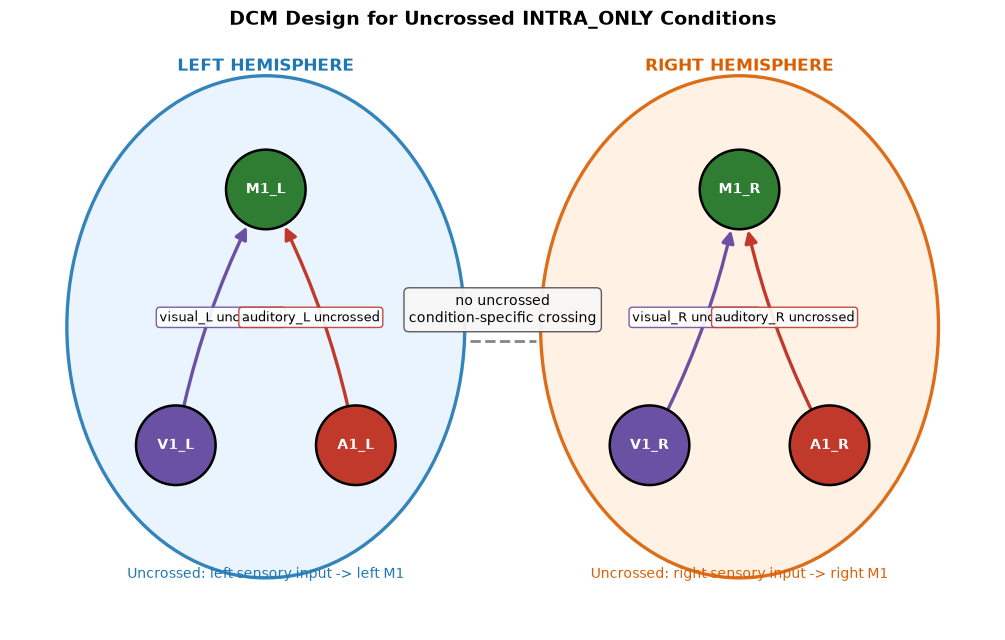

(<Figure size 1200x650 with 1 Axes>,
 <Axes: title={'center': 'DCM Design for Uncrossed INTRA_ONLY Conditions'}>)

In [9]:
from matplotlib.patches import Ellipse, Circle, FancyArrowPatch


def plot_uncrossed_dcm_design(save=True):
    """Draw explicit two-hemisphere DCM design for uncrossed INTRA_ONLY conditions."""
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.set_xlim(-5.2, 5.2)
    ax.set_ylim(-3.2, 3.1)
    ax.set_aspect("equal")
    ax.axis("off")

    left_hemi = Ellipse((-2.5, 0), 4.2, 5.3, facecolor="#E8F3FF", edgecolor="#1F77B4", lw=2.4, alpha=0.9)
    right_hemi = Ellipse((2.5, 0), 4.2, 5.3, facecolor="#FFF0E1", edgecolor="#D95F02", lw=2.4, alpha=0.9)
    ax.add_patch(left_hemi)
    ax.add_patch(right_hemi)

    ax.text(-2.5, 2.75, "LEFT HEMISPHERE", ha="center", va="center", fontsize=12, fontweight="bold", color="#1F77B4")
    ax.text(2.5, 2.75, "RIGHT HEMISPHERE", ha="center", va="center", fontsize=12, fontweight="bold", color="#D95F02")

    positions = {
        "M1_L": (-2.5, 1.45),
        "V1_L": (-3.45, -1.25),
        "A1_L": (-1.55, -1.25),
        "M1_R": (2.5, 1.45),
        "V1_R": (1.55, -1.25),
        "A1_R": (3.45, -1.25),
    }
    roi_colors = {"V1": "#6A51A3", "A1": "#C0392B", "M1": "#2E7D32"}

    for roi, (x, y) in positions.items():
        family = roi.split("_")[0]
        circ = Circle((x, y), 0.42, facecolor=roi_colors[family], edgecolor="black", lw=1.8, zorder=4)
        ax.add_patch(circ)
        ax.text(x, y, roi, ha="center", va="center", fontsize=10, color="white", fontweight="bold", zorder=5)

    def arrow(source, target, color, label=None, rad=0.0, lw=2.4):
        sx, sy = positions[source]
        tx, ty = positions[target]
        patch = FancyArrowPatch((sx, sy), (tx, ty), arrowstyle="-|>", mutation_scale=18, lw=lw, color=color,
                                shrinkA=30, shrinkB=30, connectionstyle=f"arc3,rad={rad}", zorder=3)
        ax.add_patch(patch)
        if label:
            mx, my = (sx + tx) / 2, (sy + ty) / 2
            ax.text(mx, my, label, ha="center", va="center", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor=color, alpha=0.9))

    arrow("V1_L", "M1_L", "#6A51A3", "visual_L uncrossed", rad=-0.08)
    arrow("A1_L", "M1_L", "#C0392B", "auditory_L uncrossed", rad=0.08)
    arrow("V1_R", "M1_R", "#6A51A3", "visual_R uncrossed", rad=0.08)
    arrow("A1_R", "M1_R", "#C0392B", "auditory_R uncrossed", rad=-0.08)

    ax.plot([-0.35, 0.35], [-0.15, -0.15], color="#444444", lw=2, ls="--", alpha=0.65)
    ax.text(0, 0.18, "no uncrossed\ncondition-specific crossing", ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="#F7F7F7", edgecolor="#555555", alpha=0.95))

    ax.text(-2.5, -2.65, "Uncrossed: left sensory input -> left M1", ha="center", fontsize=10, color="#1F77B4")
    ax.text(2.5, -2.65, "Uncrossed: right sensory input -> right M1", ha="center", fontsize=10, color="#D95F02")
    ax.set_title("DCM Design for Uncrossed INTRA_ONLY Conditions", fontsize=14, fontweight="bold")

    plt.tight_layout()
    if save:
        fig_path = out_dir / "dcm_uncrossed_same_hemisphere_design.png"
        fig.savefig(fig_path, dpi=180, bbox_inches="tight")
        print(f"Saved: {fig_path}")
    plt.show()
    return fig, ax


plot_uncrossed_dcm_design()

In [10]:
def process_task(task, roi_indices, force_recompute=False):
    print(f"Processing {task}")

    fmri = fmri_files[task]
    task_dir = out_dir / task
    task_dir.mkdir(exist_ok=True)

    ts_path = task_dir / "timeseries.tsv"
    u_path = task_dir / "U.tsv"

    ts = pd.read_csv(ts_path, sep="\t") if ts_path.exists() else None

    if not force_recompute and ts is not None and u_path.exists():
        U = pd.read_csv(u_path, sep="\t")
        if list(U.columns) == input_names:
            return ts, U
        print(f"  Recomputing U for {task}: cached columns do not match current condition-gated input_names")

    events = read_events_file(events_files[task])
    if ts is None or force_recompute:
        ts = extract_roi_timeseries(fmri, roi_indices)
    n_scans = len(ts)

    U = build_U(events, task, n_scans)
    A = build_A()
    B = build_B(task_name=task, pathway_type="NULL", uncrossed_policy="INTRA_ONLY")
    C = build_C()

    ts.to_csv(ts_path, sep="\t", index=False)
    U.to_csv(u_path, sep="\t", index=False)
    np.save(task_dir / "A.npy", A)
    np.save(task_dir / "C.npy", C)
    for k, v in B.items():
        np.save(task_dir / f"B_{k}.npy", v)

    return ts, U

In [11]:
roi_indices = build_roi_indices(fmri_files[tasks[0]], roi_masks)


def run_all_tasks(tasks, roi_indices, max_workers=1, force_recompute=False):
    results = {}

    # Fail early with clear messages instead of hanging in worker threads.
    missing = [
        f"{task}: {fmri_files[task]}"
        for task in tasks
        if not fmri_files[task].exists()
    ]
    if missing:
        raise FileNotFoundError("Missing fMRI files:\n" + "\n".join(missing))

    # For gzipped NIfTI on external drives, sequential processing is often faster and more stable.
    if max_workers <= 1:
        for task in tasks:
            results[task] = process_task(task, roi_indices, force_recompute=force_recompute)
        return results

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {
            pool.submit(process_task, task, roi_indices, force_recompute): task
            for task in tasks
        }
        for future in as_completed(futures):
            task = futures[future]
            try:
                results[task] = future.result()
            except Exception as e:
                print(f"Error for {task}: {e}")

    return results

In [12]:
results = run_all_tasks(tasks, roi_indices, max_workers=1, force_recompute=FORCE_RECOMPUTE)

Processing MDOD
Processing MDOG
Processing MGOG


## Build DCM specification files (SPM-ready)
This step packages each task into a DCM specification with:
- ROI timeseries (`Y.y`) and region names (`Y.name`)
- Inputs (`U.u`) and input names (`U.name`)
- Connectivity priors (`a`, `b`, `c`, `d`)
- Basic options (`options`)

Outputs are saved per task as `.mat`, `.json`, and `.npz` files in `spm_dcm_specs/`.

In [13]:
from scipy.io import savemat


def _to_matlab_cellstr(items):
    return np.array(items, dtype=object).reshape(-1, 1)


def build_dcm_spec(task, ts_df, U_df, A, B_dict, C, tr, region_names, input_names):
    # Build a minimal SPM-like DCM structure for later estimation in MATLAB/SPM.
    Y = {
        "y": ts_df.to_numpy(dtype=np.float64),
        "name": _to_matlab_cellstr(region_names),
        "dt": float(tr),
    }

    U = {
        "u": U_df.to_numpy(dtype=np.float64),
        "name": _to_matlab_cellstr(input_names),
        "dt": float(tr),
    }

    n_regions = len(region_names)

    b_stack = np.stack([B_dict[k] for k in input_names], axis=2).astype(np.float64)
    d = np.zeros((n_regions, n_regions, 0), dtype=np.float64)

    dcm = {
        "name": f"DCM_{subject_id}_{task}",
        "subject": subject_id,
        "task": task,
        "Y": Y,
        "U": U,
        "a": A.astype(np.float64),
        "b": b_stack,
        "c": C.astype(np.float64),
        "d": d,
        # Keep scalar metadata as float64 for MATLAB/SPM compatibility (avoid int64 in sparse calls).
        "n": float(n_regions),
        "v": float(ts_df.shape[0]),
        "TE": 0.04,
        "delays": np.full((n_regions, 1), tr, dtype=np.float64),
        "options": {
            "nonlinear": 0,
            "two_state": 0,
            "stochastic": 0,
            "centre": 1,
            "induced": 0,
        },
    }
    return dcm


def save_dcm_spec(task, dcm, output_dir):
    task_dir = output_dir / task
    task_dir.mkdir(parents=True, exist_ok=True)

    mat_path = task_dir / f"DCM_{subject_id}_{task}.mat"
    json_path = task_dir / f"DCM_{subject_id}_{task}.json"
    npz_path = task_dir / f"DCM_{subject_id}_{task}.npz"

    savemat(str(mat_path), {"DCM": dcm}, do_compression=True)

    json_payload = {
        "name": dcm["name"],
        "subject": dcm["subject"],
        "task": dcm["task"],
        "n_regions": int(dcm["n"]),
        "n_scans": int(dcm["v"]),
        "TR": float(dcm["Y"]["dt"]),
        "region_names": region_names,
        "input_names": input_names,
        "A": dcm["a"].tolist(),
        "C": dcm["c"].tolist(),
        "B": {k: dcm["b"][:, :, i].tolist() for i, k in enumerate(input_names)},
        "options": dcm["options"],
    }
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(json_payload, f, indent=2)

    np.savez_compressed(
        npz_path,
        y=dcm["Y"]["y"],
        u=dcm["U"]["u"],
        a=dcm["a"],
        b=dcm["b"],
        c=dcm["c"],
    )

    return {"mat": mat_path, "json": json_path, "npz": npz_path}


dcm_specs_dir = out_dir / "spm_dcm_specs"
dcm_specs_dir.mkdir(parents=True, exist_ok=True)

built_dcms = {}
for task in tasks:
    ts_task, U_task = results[task]
    A = build_A()
    B = build_B(task_name=task, pathway_type="NULL", uncrossed_policy="INTRA_ONLY")
    C = build_C()

    dcm = build_dcm_spec(
        task=task,
        ts_df=ts_task,
        U_df=U_task,
        A=A,
        B_dict=B,
        C=C,
        tr=TR,
        region_names=region_names,
        input_names=input_names,
    )
    built_dcms[task] = save_dcm_spec(task, dcm, dcm_specs_dir)

print(f"DCM specs saved to: {dcm_specs_dir}")
for task, paths in built_dcms.items():
    print(f"  {task}")
    print(f"    MAT : {paths['mat'].name}")
    print(f"    JSON: {paths['json'].name}")
    print(f"    NPZ : {paths['npz'].name}")

DCM specs saved to: /Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results/spm_dcm_specs
  MDOD
    MAT : DCM_sub-03_MDOD.mat
    JSON: DCM_sub-03_MDOD.json
    NPZ : DCM_sub-03_MDOD.npz
  MDOG
    MAT : DCM_sub-03_MDOG.mat
    JSON: DCM_sub-03_MDOG.json
    NPZ : DCM_sub-03_MDOG.npz
  MGOG
    MAT : DCM_sub-03_MGOG.mat
    JSON: DCM_sub-03_MGOG.json
    NPZ : DCM_sub-03_MGOG.npz


## 8-model DCM model-space: crossed pathway x uncrossed policy

This model-space tests crossed transfer hypotheses (`NULL`, `RELAY`, `DIRECT`, `SENSORY_RELAY`) crossed with two uncrossed policies: `UNC_INTRA_ONLY` and `UNC_FLEX`. The key question is whether BMS prefers the extra uncrossed inter-hemispheric candidates in `UNC_FLEX`, or whether intra-hemispheric uncrossed dynamics are sufficient.

In [14]:
# ============================================================================
# BUILD AND EXPORT 8-MODEL SPACE FOR SPM12 ESTIMATION
# ============================================================================
print("\n" + "="*100)
print("BUILDING CROSSED PATHWAY x UNCROSSED POLICY DCM MODEL SPACE")
print("="*100)

pathway_models_dir = dcm_specs_dir / "pathway_models"
pathway_models_dir.mkdir(parents=True, exist_ok=True)

CROSSED_PATHWAYS = ["NULL", "RELAY", "DIRECT", "SENSORY_RELAY"]
UNCROSSED_POLICIES = ["INTRA_ONLY", "FLEX"]


def model_name_for(pathway_type, uncrossed_policy):
    return f"{pathway_type}__UNC_{uncrossed_policy}"


def build_dcm_pathway_model(pathway_type, uncrossed_policy):
    models = {}
    for task in tasks:
        A = build_A()
        B = build_B(task_name=task, pathway_type=pathway_type, uncrossed_policy=uncrossed_policy)
        C = build_C()
        models[task] = {"A": A, "B": B, "C": C, "crossed_pathway": pathway_type, "uncrossed_policy": uncrossed_policy}
    return models


pathway_specs = {}
pathway_metadata = {}
for crossed_pathway in CROSSED_PATHWAYS:
    for uncrossed_policy in UNCROSSED_POLICIES:
        name = model_name_for(crossed_pathway, uncrossed_policy)
        pathway_specs[name] = build_dcm_pathway_model(crossed_pathway, uncrossed_policy)
        pathway_metadata[name] = {"crossed_pathway": crossed_pathway, "uncrossed_policy": uncrossed_policy}

print("\nModel families built:")
for model_name, meta in pathway_metadata.items():
    print(f"  ✓ {model_name}: crossed={meta['crossed_pathway']}, uncrossed={meta['uncrossed_policy']}")

pathway_outputs = {}
for model_name, task_models in pathway_specs.items():
    print(f"\n{model_name}:")
    pathway_dir = pathway_models_dir / model_name
    pathway_dir.mkdir(parents=True, exist_ok=True)
    pathway_outputs[model_name] = {}
    meta = pathway_metadata[model_name]

    for task in tasks:
        ts_df, U_df = results[task]
        dcm_pw = build_dcm_spec(
            task=task,
            ts_df=ts_df,
            U_df=U_df,
            A=task_models[task]["A"],
            B_dict=task_models[task]["B"],
            C=task_models[task]["C"],
            tr=TR,
            region_names=region_names,
            input_names=input_names,
        )
        dcm_pw["name"] = f"DCM_{subject_id}_{task}_{model_name}"

        task_pw_dir = pathway_dir / task
        task_pw_dir.mkdir(parents=True, exist_ok=True)
        mat_file = task_pw_dir / f"DCM_{subject_id}_{task}_{model_name}.mat"
        json_file = task_pw_dir / f"DCM_{subject_id}_{task}_{model_name}.json"
        npz_file = task_pw_dir / f"DCM_{subject_id}_{task}_{model_name}.npz"

        savemat(str(mat_file), {"DCM": dcm_pw}, do_compression=True)
        json_payload = {
            "name": dcm_pw["name"],
            "subject": dcm_pw["subject"],
            "task": dcm_pw["task"],
            "model_name": model_name,
            "crossed_pathway": meta["crossed_pathway"],
            "uncrossed_policy": meta["uncrossed_policy"],
            "n_regions": int(dcm_pw["n"]),
            "n_scans": int(dcm_pw["v"]),
            "TR": float(dcm_pw["Y"]["dt"]),
            "region_names": region_names,
            "input_names": input_names,
            "A": dcm_pw["a"].tolist(),
            "C": dcm_pw["c"].tolist(),
            "B": {k: dcm_pw["b"][:, :, i].tolist() for i, k in enumerate(input_names)},
            "options": dcm_pw["options"],
        }
        with open(json_file, "w", encoding="utf-8") as f:
            json.dump(json_payload, f, indent=2)
        np.savez_compressed(npz_file, y=dcm_pw["Y"]["y"], u=dcm_pw["U"]["u"], a=dcm_pw["a"], b=dcm_pw["b"], c=dcm_pw["c"])
        pathway_outputs[model_name][task] = {"mat": mat_file, "json": json_file, "npz": npz_file}
        print(f"  ✓ {task}: MAT/JSON/NPZ exported")

print("\n" + "="*100)
print(f"All 8-model DCMs saved to: {pathway_models_dir}")
print("="*100)


BUILDING CROSSED PATHWAY x UNCROSSED POLICY DCM MODEL SPACE

Model families built:
  ✓ NULL__UNC_INTRA_ONLY: crossed=NULL, uncrossed=INTRA_ONLY
  ✓ NULL__UNC_FLEX: crossed=NULL, uncrossed=FLEX
  ✓ RELAY__UNC_INTRA_ONLY: crossed=RELAY, uncrossed=INTRA_ONLY
  ✓ RELAY__UNC_FLEX: crossed=RELAY, uncrossed=FLEX
  ✓ DIRECT__UNC_INTRA_ONLY: crossed=DIRECT, uncrossed=INTRA_ONLY
  ✓ DIRECT__UNC_FLEX: crossed=DIRECT, uncrossed=FLEX
  ✓ SENSORY_RELAY__UNC_INTRA_ONLY: crossed=SENSORY_RELAY, uncrossed=INTRA_ONLY
  ✓ SENSORY_RELAY__UNC_FLEX: crossed=SENSORY_RELAY, uncrossed=FLEX

NULL__UNC_INTRA_ONLY:
  ✓ MDOD: MAT/JSON/NPZ exported
  ✓ MDOG: MAT/JSON/NPZ exported
  ✓ MGOG: MAT/JSON/NPZ exported

NULL__UNC_FLEX:
  ✓ MDOD: MAT/JSON/NPZ exported
  ✓ MDOG: MAT/JSON/NPZ exported
  ✓ MGOG: MAT/JSON/NPZ exported

RELAY__UNC_INTRA_ONLY:
  ✓ MDOD: MAT/JSON/NPZ exported
  ✓ MDOG: MAT/JSON/NPZ exported
  ✓ MGOG: MAT/JSON/NPZ exported

RELAY__UNC_FLEX:
  ✓ MDOD: MAT/JSON/NPZ exported
  ✓ MDOG: MAT/JSON/NPZ exp

In [15]:
# ============================================================================
# GENERATE SPM12 MATLAB BATCH SCRIPT FOR 8-MODEL COMPARISON
# ============================================================================
print("\n" + "="*100)
print("GENERATING SPM12 MATLAB BATCH SCRIPT FOR 8-MODEL COMPARISON")
print("="*100)

from datetime import datetime

matlab_batch_file = pathway_models_dir / "run_pathway_dcm_estimation_bms_unique.m"
model_names_all = list(pathway_specs.keys())

lines = []
lines.append("% Auto-generated DCM estimation MATLAB script (8-model version)")
lines.append(f"% Generated on {datetime.now().isoformat(timespec='seconds')}")
lines.append(f"% Subject: {subject_id}")
lines.append("% Models: " + ", ".join(model_names_all))
lines.append("%")
lines.append("% REQUIREMENTS:")
lines.append("%   - SPM12 on MATLAB path")
lines.append(f"%   - DCM files exported in: {str(pathway_models_dir)}")
lines.append("")
lines.append("clear DCM_files estimated_DCM_files;")
lines.append(f"base_dir = '{str(pathway_models_dir)}';")
lines.append("tasks = {" + ", ".join([f"'{t}'" for t in tasks]) + "};")
lines.append("models = {" + ", ".join([f"'{m}'" for m in model_names_all]) + "};")
lines.append("fprintf('Estimating %d DCM models across %d tasks\\n', numel(models), numel(tasks));")
lines.append("")
lines.append("for t = 1:numel(tasks)")
lines.append("    task = tasks{t};")
lines.append("    fprintf('\\nTask %s\\n', task);")
lines.append("    F_values = zeros(1, numel(models));")
lines.append("    for m = 1:numel(models)")
lines.append("        model = models{m};")
lines.append(f"        dcm_file = fullfile(base_dir, model, task, sprintf('DCM_{subject_id}_%s_%s.mat', task, model));")
lines.append("        if ~exist(dcm_file, 'file')")
lines.append("            error('Missing DCM file: %s', dcm_file);")
lines.append("        end")
lines.append("        D = load(dcm_file);")
lines.append("        DCM = D.DCM;")
lines.append("        DCM.name = erase(dcm_file, '.mat');")
lines.append("        fprintf('  Estimating %s...\\n', model);")
lines.append("        DCM_est = spm_dcm_estimate(DCM);")
lines.append("        F_values(m) = DCM_est.F;")
lines.append("        save(dcm_file, 'DCM_est');")
lines.append("    end")
lines.append("")
lines.append("    bms_dir = fullfile(base_dir, task, 'BMS_unique');")
lines.append("    if ~exist(bms_dir, 'dir'), mkdir(bms_dir); end")
lines.append("    ")
lines.append("    F_file = fullfile(bms_dir, 'F_values.mat');")
lines.append("    save(F_file, 'F_values', 'models');")
lines.append("    fprintf('  Saved F values for BMS: %s\\n', F_file);")
lines.append("end")
lines.append("")
lines.append("fprintf('\\nDCM estimations complete. F values saved for BMS analysis in Python.\\n');")

with open(matlab_batch_file, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"✓ MATLAB script generated: {matlab_batch_file}")
print("Models:", ", ".join(model_names_all))
print("\nNote: BMS analysis will be done in Python after MATLAB/SPM completes.")


GENERATING SPM12 MATLAB BATCH SCRIPT FOR 8-MODEL COMPARISON
✓ MATLAB script generated: /Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results/spm_dcm_specs/pathway_models/run_pathway_dcm_estimation_bms_unique.m
Models: NULL__UNC_INTRA_ONLY, NULL__UNC_FLEX, RELAY__UNC_INTRA_ONLY, RELAY__UNC_FLEX, DIRECT__UNC_INTRA_ONLY, DIRECT__UNC_FLEX, SENSORY_RELAY__UNC_INTRA_ONLY, SENSORY_RELAY__UNC_FLEX

Note: BMS analysis will be done in Python after MATLAB/SPM completes.


## Run MATLAB/SPM estimation from the notebook

Set `RUN_MATLAB = True` in the setup cell when you want this cell to launch SPM estimation and BMS for the 8-model space. Leave it `False` while editing or regenerating specs.

In [16]:
# ============================================================================
# RUN MATLAB/SPM ESTIMATION FROM NOTEBOOK
# ============================================================================
print("\n" + "="*100)
print("RUN MATLAB/SPM ESTIMATION FOR 8-MODEL SPACE")
print("="*100)

import shutil
import subprocess

candidate_matlab_bins = [
    shutil.which("matlab"),
    "/Applications/MATLAB_R2025b.app/bin/matlab",
    "/Applications/MATLAB_R2025a.app/bin/matlab",
    "/Applications/MATLAB_R2024b.app/bin/matlab",
    "/home/lea/MATLAB/R2025b/bin/matlab",
    "/home/lea/Matlab/R2025b/bin/matlab",
    "/usr/local/MATLAB/R2025b/bin/matlab",
]
matlab_executable = next((path for path in candidate_matlab_bins if path and Path(path).exists()), None)
matlab_batch_path = pathway_models_dir / "run_pathway_dcm_estimation_bms_unique.m"
matlab_log_path = pathway_models_dir / "matlab_spm_8model_run.log"

spm12_dir_candidates = [
    Path("/Users/neilabenlamri/spm12"),
    Path("/Users/neilabenlamri/Documents/MATLAB/spm12"),
    Path("/Applications/spm12"),
    Path("/home/lea/MATLAB/spm"),
    Path("/Users/alex/Documents/MATLAB/spm"),
]
spm12_dir = next((path for path in spm12_dir_candidates if path.exists()), spm12_dir_candidates[0])
matlab_command = f"addpath(genpath('{spm12_dir}')); cd('{pathway_models_dir}'); run('{matlab_batch_path}');"

if not RUN_MATLAB:
    print("MATLAB launch skipped because RUN_MATLAB=False.")
    print("Set RUN_MATLAB=True in the setup cell to launch MATLAB/SPM from this notebook.")
    print(f"MATLAB executable: {matlab_executable or 'not found'}")
    print(f"SPM12 path: {spm12_dir}")
    print(f"Batch script: {matlab_batch_path}")
elif matlab_executable is None:
    raise FileNotFoundError("MATLAB executable not found. Add your MATLAB path to candidate_matlab_bins.")
elif not matlab_batch_path.exists():
    raise FileNotFoundError(f"MATLAB batch script not found: {matlab_batch_path}. Run the script-generation cell first.")
else:
    cmd = [str(matlab_executable), "-batch", matlab_command]
    print("Running:", " ".join(cmd))
    print(f"Log file: {matlab_log_path}")
    with open(matlab_log_path, "w", encoding="utf-8") as log:
        completed = subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, text=True)
    if completed.returncode != 0:
        print(f"MATLAB/SPM failed with exit code {completed.returncode}. See log: {matlab_log_path}")
    else:
        print("MATLAB/SPM estimation and BMS completed successfully.")


RUN MATLAB/SPM ESTIMATION FOR 8-MODEL SPACE
Running: /Applications/MATLAB_R2025a.app/bin/matlab -batch addpath(genpath('/Users/alex/Documents/MATLAB/spm')); cd('/Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results/spm_dcm_specs/pathway_models'); run('/Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results/spm_dcm_specs/pathway_models/run_pathway_dcm_estimation_bms_unique.m');
Log file: /Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results/spm_dcm_specs/pathway_models/matlab_spm_8model_run.log
MATLAB/SPM estimation and BMS completed successfully.


In [17]:
# ============================================================================
# LOAD & ANALYZE 8-MODEL BMS RESULTS
# ============================================================================
print("\n" + "=" * 100)
print("ANALYZING 8-MODEL BAYESIAN MODEL SELECTION RESULTS")
print("=" * 100)

from scipy.io import loadmat

# --- CORRECTION DE CHEMIN : Force la mise à jour par rapport au nouvel out_dir ---
out_dir = events_dir / "dcm_results"
pathway_models_dir = out_dir / "spm_dcm_specs" / "pathway_models"

if "pathway_specs" not in globals():
    raise RuntimeError("Run the 8-model model-space export cell first so pathway_specs is available.")


def compute_bms_posterior(F_values):
    """Compute BMS posterior from free energy (log model evidence) values."""
    F_values = np.asarray(F_values, dtype=float).flatten()
    # Normalize by subtracting max for numerical stability
    F_norm = F_values - F_values.max()
    # Compute model probabilities (softmax on log evidences)
    posterior = np.exp(F_norm) / np.sum(np.exp(F_norm))
    return posterior


model_labels = list(pathway_specs.keys())
bms_results_modelspace = {}
rows = []

print(f"Recherche des fichiers .mat dans : {pathway_models_dir}\n")

for task in tasks:
    bms_dir = pathway_models_dir / task / "BMS_unique"
    f_file = bms_dir / "F_values.mat"

    if not f_file.exists():
        print(f"⚠ {task}: F_values.mat not found at {f_file}")
        continue

    # Load F values from MATLAB .mat file
    mat_data = loadmat(str(f_file))
    F_values = mat_data["F_values"].flatten()

    # Compute posterior probabilities
    post = compute_bms_posterior(F_values)

    bms_results_modelspace[task] = {"post": post, "labels": model_labels, "file": f_file}
    row = {"Task": task}
    winner_idx = int(np.argmax(post))
    row["Winner"] = model_labels[winner_idx]
    row["WinnerPosterior"] = float(post[winner_idx])
    for label, value in zip(model_labels, post):
        row[label] = float(value)
    rows.append(row)
    print(f"✓ {task}: winner={model_labels[winner_idx]} ({post[winner_idx] * 100:.1f}%)")

if not rows:
    raise RuntimeError(
        f"No BMS results could be loaded. Vérifiez manuellement la présence de F_values.mat dans {pathway_models_dir}")

summary_df_modelspace = pd.DataFrame(rows)
print("\nTask-level 8-model posterior summary")
print(summary_df_modelspace.to_string(index=False))

# Summarize by uncrossed policy
policy_rows = []
for task, item in bms_results_modelspace.items():
    for label, posterior in zip(item["labels"], item["post"]):
        meta = pathway_metadata.get(label, {})
        policy_rows.append({
            "Task": task,
            "Model": label,
            "CrossedPathway": meta.get("crossed_pathway"),
            "UncrossedPolicy": meta.get("uncrossed_policy"),
            "Posterior": float(posterior),
        })
policy_df = pd.DataFrame(policy_rows)
policy_summary = policy_df.groupby("UncrossedPolicy", as_index=False)["Posterior"].mean()
print("\nMean posterior by uncrossed policy")
print(policy_summary.to_string(index=False))

# --- SAUVEGARDE SÉCURISÉE ---
summary_df_modelspace.to_csv(out_dir / "bms_8model_summary.csv", index=False)
policy_summary.to_csv(out_dir / "bms_uncrossed_policy_summary.csv", index=False)
print(f"\n✓ Rapports CSV sauvegardés avec succès dans : {out_dir}")


ANALYZING 8-MODEL BAYESIAN MODEL SELECTION RESULTS
Recherche des fichiers .mat dans : /Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results/spm_dcm_specs/pathway_models

✓ MDOD: winner=RELAY__UNC_FLEX (58.2%)
✓ MDOG: winner=RELAY__UNC_FLEX (73.3%)
✓ MGOG: winner=SENSORY_RELAY__UNC_FLEX (98.3%)

Task-level 8-model posterior summary
Task                  Winner  WinnerPosterior  NULL__UNC_INTRA_ONLY  NULL__UNC_FLEX  RELAY__UNC_INTRA_ONLY  RELAY__UNC_FLEX  DIRECT__UNC_INTRA_ONLY  DIRECT__UNC_FLEX  SENSORY_RELAY__UNC_INTRA_ONLY  SENSORY_RELAY__UNC_FLEX
MDOD         RELAY__UNC_FLEX         0.581962          5.489356e-14    1.409463e-01           5.469870e-14         0.581962            1.750018e-13      9.307026e-02                   3.354294e-13                 0.184021
MDOG         RELAY__UNC_FLEX         0.733174          1.156693e-18    2.815458e-15           1.906025e-01         0.733174            3.497703e-14      3.480313e-1

In [18]:
# ============================================================================
# 8-MODEL BMS RESULTS CHECK
# ============================================================================
print("\n" + "="*100)
print("8-MODEL BMS RESULTS CHECK")
print("="*100)

if "bms_results_modelspace" not in globals() or not bms_results_modelspace:
    raise RuntimeError("Run the 8-model BMS analysis cell first.")

for task, item in bms_results_modelspace.items():
    labels = item["labels"]
    post = item["post"]
    winner_idx = int(np.argmax(post))
    print(f"✓ {task}: {len(labels)} models from {item['file'].parent.name}")
    for label, value in zip(labels, post):
        print(f"    {label:34s}: {value*100:6.2f}%")
    print(f"    Winner: {labels[winner_idx]} ({post[winner_idx]*100:.1f}%)")


8-MODEL BMS RESULTS CHECK
✓ MDOD: 8 models from BMS_unique
    NULL__UNC_INTRA_ONLY              :   0.00%
    NULL__UNC_FLEX                    :  14.09%
    RELAY__UNC_INTRA_ONLY             :   0.00%
    RELAY__UNC_FLEX                   :  58.20%
    DIRECT__UNC_INTRA_ONLY            :   0.00%
    DIRECT__UNC_FLEX                  :   9.31%
    SENSORY_RELAY__UNC_INTRA_ONLY     :   0.00%
    SENSORY_RELAY__UNC_FLEX           :  18.40%
    Winner: RELAY__UNC_FLEX (58.2%)
✓ MDOG: 8 models from BMS_unique
    NULL__UNC_INTRA_ONLY              :   0.00%
    NULL__UNC_FLEX                    :   0.00%
    RELAY__UNC_INTRA_ONLY             :  19.06%
    RELAY__UNC_FLEX                   :  73.32%
    DIRECT__UNC_INTRA_ONLY            :   0.00%
    DIRECT__UNC_FLEX                  :   0.00%
    SENSORY_RELAY__UNC_INTRA_ONLY     :   0.00%
    SENSORY_RELAY__UNC_FLEX           :   7.62%
    Winner: RELAY__UNC_FLEX (73.3%)
✓ MGOG: 8 models from BMS_unique
    NULL__UNC_INTRA_ONLY          


CREATING MODEL-SPACE BMS RESULTS FIGURE


/var/folders/gx/xfh0rzwj1ln9z7n6lpv93b_00000gn/T/ipykernel_26421/159866787.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(all_labels, rotation=35, ha="right")


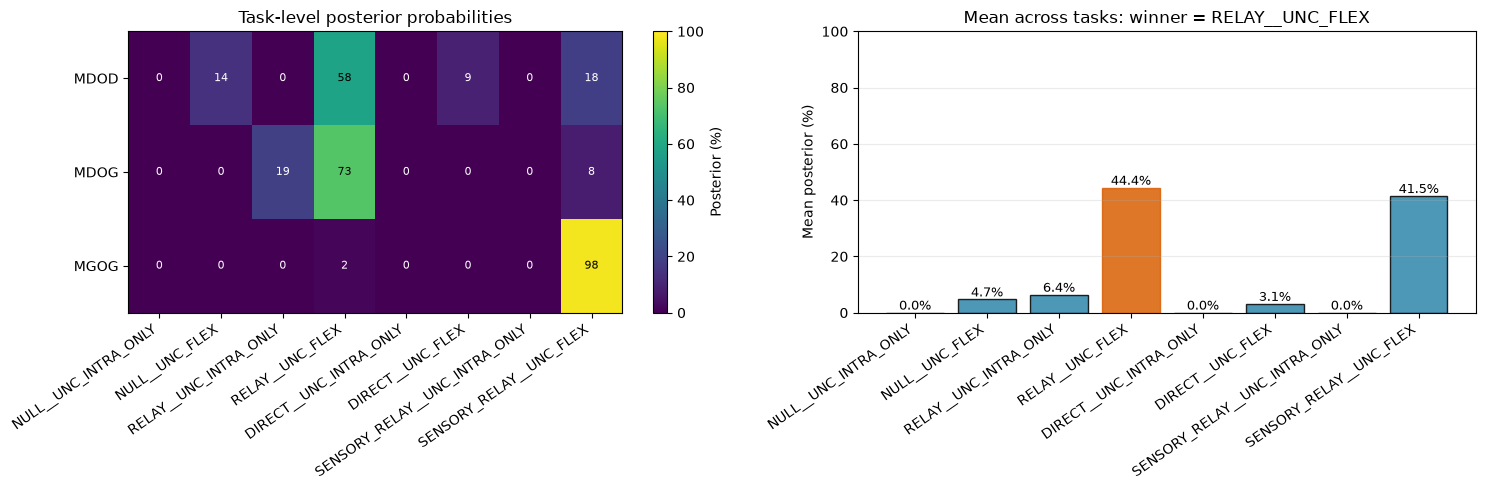

✓ Saved: /Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results/dcm_modelspace_results_summary.png
Overall winner: RELAY__UNC_FLEX (44.4%)


In [19]:
# ============================================================================
# VISUALIZE MODEL-SPACE BMS RESULTS
# ============================================================================
print("\n" + "="*100)
print("CREATING MODEL-SPACE BMS RESULTS FIGURE")
print("="*100)

import matplotlib.pyplot as plt
import numpy as np

if "bms_results_modelspace" not in globals() or not bms_results_modelspace:
    raise RuntimeError("Run the model-space BMS analysis cell first.")

all_labels = []
for item in bms_results_modelspace.values():
    for label in item["labels"]:
        if label not in all_labels:
            all_labels.append(label)

task_names = [task for task in tasks if task in bms_results_modelspace]
posterior_matrix = np.full((len(task_names), len(all_labels)), np.nan)
for i, task in enumerate(task_names):
    item = bms_results_modelspace[task]
    for label, value in zip(item["labels"], item["post"]):
        posterior_matrix[i, all_labels.index(label)] = value * 100

mean_values = np.nanmean(posterior_matrix, axis=0)
winner_idx = int(np.nanargmax(mean_values))
winner_label = all_labels[winner_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im = axes[0].imshow(posterior_matrix, aspect="auto", cmap="viridis", vmin=0, vmax=100)
axes[0].set_xticks(range(len(all_labels)))
axes[0].set_xticklabels(all_labels, rotation=35, ha="right")
axes[0].set_yticks(range(len(task_names)))
axes[0].set_yticklabels(task_names)
axes[0].set_title("Task-level posterior probabilities")
for i in range(len(task_names)):
    for j in range(len(all_labels)):
        val = posterior_matrix[i, j]
        if np.isfinite(val):
            axes[0].text(j, i, f"{val:.0f}", ha="center", va="center", color="white" if val < 55 else "black", fontsize=8)
fig.colorbar(im, ax=axes[0], label="Posterior (%)")

bars = axes[1].bar(all_labels, mean_values, color="#2E86AB", alpha=0.85, edgecolor="black")
bars[winner_idx].set_color("#D95F02")
for bar, value in zip(bars, mean_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1].set_ylim(0, max(100, np.nanmax(mean_values) * 1.15))
axes[1].set_ylabel("Mean posterior (%)")
axes[1].set_title(f"Mean across tasks: winner = {winner_label}")
axes[1].grid(axis="y", alpha=0.25)
axes[1].set_xticklabels(all_labels, rotation=35, ha="right")

plt.tight_layout()
results_fig = out_dir / "dcm_modelspace_results_summary.png"
fig.savefig(results_fig, dpi=180, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {results_fig}")
print(f"Overall winner: {winner_label} ({mean_values[winner_idx]:.1f}%)")


CONNECTIVITY MAP FROM WINNING MODEL


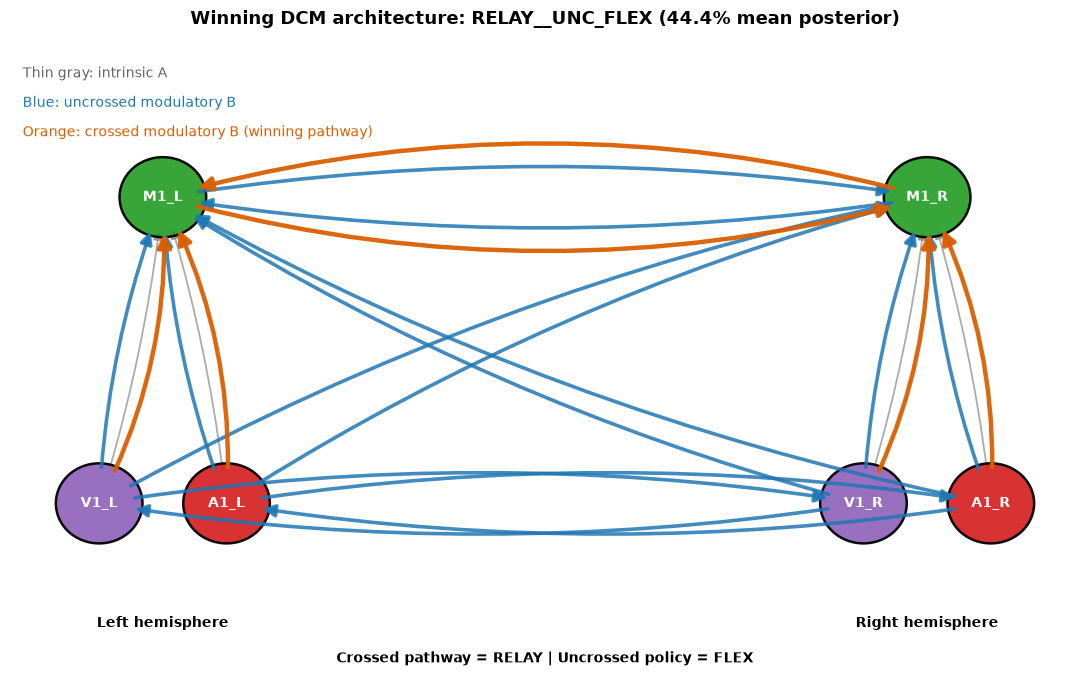

✓ Saved: /Users/alex/university/Neuroscience_Master/short-term internship/derivatives_MNIcohort3/sub-03/func/dcm_results/dcm_winning_architecture_map.png
Crossed edges shown: 6 | Uncrossed edges shown: 14


In [20]:
# ============================================================================
# CONNECTIVITY MAP FROM WINNING MODEL-SPACE ARCHITECTURE
# ============================================================================
print("\n" + "="*100)
print("CONNECTIVITY MAP FROM WINNING MODEL")
print("="*100)

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
import numpy as np

if "bms_results_modelspace" not in globals() or not bms_results_modelspace:
    raise RuntimeError("Run the model-space BMS analysis cell first.")
if "pathway_specs" not in globals():
    raise RuntimeError("Run the pathway model-building cell first so pathway_specs is available.")

all_labels = []
for item in bms_results_modelspace.values():
    for label in item["labels"]:
        if label not in all_labels:
            all_labels.append(label)

mean_post = {}
for label in all_labels:
    vals = []
    for item in bms_results_modelspace.values():
        if label in item["labels"]:
            vals.append(item["post"][item["labels"].index(label)])
    mean_post[label] = float(np.mean(vals))

winner_label = max(mean_post, key=mean_post.get)
if winner_label not in pathway_specs:
    raise RuntimeError(f"Winning label {winner_label} is not in current pathway_specs.")

A_win = pathway_specs[winner_label][tasks[0]]["A"]
B_win = pathway_specs[winner_label][tasks[0]]["B"]

positions = {
    "M1_L": np.array([-3.0, 1.4]), "V1_L": np.array([-3.5, -1.2]), "A1_L": np.array([-2.5, -1.2]),
    "M1_R": np.array([3.0, 1.4]), "V1_R": np.array([2.5, -1.2]), "A1_R": np.array([3.5, -1.2]),
}
idx_to_name = {0: "M1_L", 1: "M1_R", 2: "A1_L", 3: "A1_R", 4: "V1_L", 5: "V1_R"}
colors = {"V1": "#9467bd", "A1": "#d62728", "M1": "#2ca02c"}

fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-2.7, 2.8)
ax.axis("off")
ax.set_title(
    f"Winning DCM architecture: {winner_label} ({mean_post.get(winner_label, np.nan)*100:.1f}% mean posterior)",
    fontsize=13,
    fontweight="bold",
)

for name, pos in positions.items():
    family = name.split("_")[0]
    circle = Circle(pos, 0.34, color=colors[family], ec="black", lw=1.8, alpha=0.95, zorder=4)
    ax.add_patch(circle)
    ax.text(pos[0], pos[1], name, ha="center", va="center", color="white", fontsize=10, fontweight="bold", zorder=5)

# 1) Draw intrinsic A connections (thin, neutral) as structural baseline.
for target in range(A_win.shape[0]):
    for source in range(A_win.shape[1]):
        if source == target or A_win[target, source] == 0:
            continue
        source_name = idx_to_name[source]
        target_name = idx_to_name[target]
        start = positions[source_name]
        end = positions[target_name]

        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=14,
            lw=1.3,
            color="#888888",
            alpha=0.7,
            shrinkA=24,
            shrinkB=24,
            connectionstyle="arc3,rad=0.05",
            zorder=2,
        )
        ax.add_patch(arrow)

# 2) Extract pathway-defining B connections from winner model.
#    We separate crossed vs uncrossed modulatory families to show the winning pathway logic.
crossed_edges = set()
uncrossed_edges = set()
for input_name, Bm in B_win.items():
    is_crossed = input_name.endswith("_crossed")
    nz = np.argwhere(Bm != 0)
    for target_idx, source_idx in nz:
        edge = (int(source_idx), int(target_idx))
        if is_crossed:
            crossed_edges.add(edge)
        else:
            uncrossed_edges.add(edge)

# Draw uncrossed modulatory edges (blue).
for source_idx, target_idx in sorted(uncrossed_edges):
    source_name = idx_to_name[source_idx]
    target_name = idx_to_name[target_idx]
    start = positions[source_name]
    end = positions[target_name]
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        lw=2.6,
        color="#1f77b4",
        alpha=0.85,
        shrinkA=26,
        shrinkB=26,
        connectionstyle="arc3,rad=-0.08",
        zorder=6,
    )
    ax.add_patch(arrow)

# Draw crossed modulatory edges (orange) = main discriminative pathway in this model-space.
for source_idx, target_idx in sorted(crossed_edges):
    source_name = idx_to_name[source_idx]
    target_name = idx_to_name[target_idx]
    start = positions[source_name]
    end = positions[target_name]
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=20,
        lw=3.2,
        color="#d95f02",
        alpha=0.95,
        shrinkA=26,
        shrinkB=26,
        connectionstyle="arc3,rad=0.14",
        zorder=7,
    )
    ax.add_patch(arrow)

ax.text(-3.0, -2.25, "Left hemisphere", ha="center", fontsize=10, fontweight="bold")
ax.text(3.0, -2.25, "Right hemisphere", ha="center", fontsize=10, fontweight="bold")

# Compact legend as on-figure text to keep notebook portable.
ax.text(-4.1, 2.45, "Thin gray: intrinsic A", fontsize=10, color="#666666", ha="left", va="center")
ax.text(-4.1, 2.20, "Blue: uncrossed modulatory B", fontsize=10, color="#1f77b4", ha="left", va="center")
ax.text(-4.1, 1.95, "Orange: crossed modulatory B (winning pathway)", fontsize=10, color="#d95f02", ha="left", va="center")

meta = pathway_metadata.get(winner_label, {})
ax.text(
    0,
    -2.55,
    f"Crossed pathway = {meta.get('crossed_pathway', 'n/a')} | Uncrossed policy = {meta.get('uncrossed_policy', 'n/a')}",
    ha="center",
    fontsize=10,
    fontweight="bold",
)

plt.tight_layout()
map_fig = out_dir / "dcm_winning_architecture_map.png"
fig.savefig(map_fig, dpi=180, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {map_fig}")
print(f"Crossed edges shown: {len(crossed_edges)} | Uncrossed edges shown: {len(uncrossed_edges)}")